In [1]:
import numpy as np
import pandas as pd
import json
from itertools import combinations
import itertools
import random
from collections import defaultdict
import os
import shutil
import ast
from matplotlib import pyplot as plt
import pickle
import json
import random
from collections import defaultdict
from itertools import combinations
from itertools import permutations
from itertools import product
import pickle
from scipy.stats import kendalltau
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from scipy.stats import mannwhitneyu
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mutual_info_score
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [2]:
os.chdir('/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update')
os.getcwd()

'/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update'

### Preparation work

In [3]:
# Read in the dataframes
def DownloadAndRenaming(path):
    df = pd.read_csv(path)

    if path == "/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/Jan 28 update/Gene_Mutation_Trimmed.csv":
        df = df.rename(columns={"gene name": "Gene"})
        df = df.set_index("Gene")

    else:
        df = df.rename(columns={"Unnamed: 0": "Gene"})
        df = df.set_index("Gene")
    
    return df

cancer_complexes = pd.read_excel('/Users/guowanyi/Desktop/fall_2025/Louis_Vuitton/Nov24_update_required_files/cancer_complexes_clean.xlsx', index_col = 0)
cancer_complexes["Representative Genes (Core Members)"] = (cancer_complexes["Representative Genes (Core Members)"].apply(ast.literal_eval))


Gene_expression = DownloadAndRenaming('/Users/guowanyi/Desktop/fall_2025/Louis_Vuitton/Nov24_update_required_files/DepMap_Trimmed/Gene_Expression_Trimmed.csv')
shRNA = DownloadAndRenaming('/Users/guowanyi/Desktop/fall_2025/Louis_Vuitton/Nov24_update_required_files/DepMap_Trimmed/shRNA_Trimmed.csv')
CRISPR = DownloadAndRenaming('/Users/guowanyi/Desktop/fall_2025/Louis_Vuitton/Nov24_update_required_files/DepMap_Trimmed/CRISPR_Trimmed.csv')
Gene_mutation = DownloadAndRenaming('/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/Jan 28 update/Gene_Mutation_Trimmed.csv')
copy_number = DownloadAndRenaming('/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/Jan 28 update/Copy_Number_Trimmed.csv')

In [4]:
matrices = {
    'CRISPR' : CRISPR,
    'Gene_expression' : Gene_expression,
    'shRNA' : shRNA,
    "copy_number": copy_number,
    "Gene_mutation": Gene_mutation

}

matrixNames = list(matrices.keys())
matrix_pairs = list(product(matrixNames, repeat = 2))
print(matrix_pairs)

[('CRISPR', 'CRISPR'), ('CRISPR', 'Gene_expression'), ('CRISPR', 'shRNA'), ('CRISPR', 'copy_number'), ('CRISPR', 'Gene_mutation'), ('Gene_expression', 'CRISPR'), ('Gene_expression', 'Gene_expression'), ('Gene_expression', 'shRNA'), ('Gene_expression', 'copy_number'), ('Gene_expression', 'Gene_mutation'), ('shRNA', 'CRISPR'), ('shRNA', 'Gene_expression'), ('shRNA', 'shRNA'), ('shRNA', 'copy_number'), ('shRNA', 'Gene_mutation'), ('copy_number', 'CRISPR'), ('copy_number', 'Gene_expression'), ('copy_number', 'shRNA'), ('copy_number', 'copy_number'), ('copy_number', 'Gene_mutation'), ('Gene_mutation', 'CRISPR'), ('Gene_mutation', 'Gene_expression'), ('Gene_mutation', 'shRNA'), ('Gene_mutation', 'copy_number'), ('Gene_mutation', 'Gene_mutation')]


In [6]:
# Read in the positive controls
with open('/Users/guowanyi/Desktop/fall_2025/Louis_Vuitton/Nov24_update_required_files/Ten_positive_controls_1119.pkl', "rb") as f:
    Ten_positive_controls_1119 = pickle.load(f)

In [7]:
# Read in the fixed negative controls
with open('/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/Feb 25 update/Fixed_10_negative_controls0223.pkl', "rb") as f:
    Fixed_10_negative_controls = pickle.load(f)

In [8]:
# Convert the control dictionary to data frame
def convert2genePairDF(control_dict, controlType = ["positive", "negative"]):

    if isinstance(control_dict, pd.DataFrame):
        genePairDF = control_dict.copy()

    else: 

        if controlType == "negative":
            genePairDF = pd.DataFrame(control_dict, columns=["Gene1", "Gene2"])
        else:
            rows = []

            for complex_name, gene_pairs in control_dict.items():
                for g1, g2 in gene_pairs:
                    rows.append([g1, g2, complex_name])

            genePairDF = pd.DataFrame(rows, columns=["Gene1", "Gene2", "Complex"])

    
    return genePairDF

In [9]:
# Initialize a demo set for testing the codes

all_complexes = cancer_complexes["Complex Name"].to_list()
test_held_out_complex = all_complexes[26]

positive1 = Ten_positive_controls_1119["positive_control_1"]
positive1_df = convert2genePairDF(positive1, "positive")

negative1 = Fixed_10_negative_controls["negative_controls_1"]
negative1_df = convert2genePairDF(negative1, "negative")

print(f'The identity of the held_out complex for testing is {test_held_out_complex}')

The identity of the held_out complex for testing is ISR/EIF2α–ATF4 complex


In [10]:
# A computation function
def bicor(x, y, c = 9.0):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Remove missing values
    mask = (~np.isnan(x)) & (~np.isnan(y))
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return np.nan

    # Median and MAD
    x_med = np.median(x)
    y_med = np.median(y)

    x_mad = np.median(np.abs(x - x_med))
    y_mad = np.median(np.abs(y - y_med))
    
    if x_mad == 0 or y_mad == 0: 
        return np.nan

    # Standardized distances
    ux = (x - x_med) / (c * x_mad)
    uy = (y - y_med) / (c * y_mad)

    # Weights
    wx = (1 - ux**2)**2
    wy = (1 - uy**2)**2
    wx[np.abs(ux) >= 1] = 0
    wy[np.abs(uy) >= 1] = 0

    # Weighted values
    xw = (x - x_med) * wx
    yw = (y - y_med) * wy

    numerator = np.sum(xw * yw)
    denominator = np.sqrt(np.sum(xw**2) * np.sum(yw**2))

    return numerator / denominator if denominator != 0 else np.nan

In [11]:
def computeAllFeatures(ctrl_df, matrices, matrix_pairs, method):

    rows = []

    # ---- Precompute alignment ----
    pair_data = {}

    for m1_name, m2_name in matrix_pairs:

        df1 = matrices[m1_name]
        df2 = matrices[m2_name]

        commonSamples = df1.columns.intersection(df2.columns)

        pair_data[(m1_name, m2_name)] = {
            "df1": df1[commonSamples],
            "df2": df2[commonSamples]
        }

    # ---- Main loop ----
    for pair_row in ctrl_df.itertuples(index=False):

        gene1 = pair_row.Gene1
        gene2 = pair_row.Gene2

        row = {"Gene_pair": f"{gene1}_{gene2}"}

        for (m1_name, m2_name), info in pair_data.items():

            df1 = info["df1"]
            df2 = info["df2"]

            feature_name = f"{m1_name}_vs_{m2_name}"

            if gene1 not in df1.index or gene2 not in df2.index:
                row[feature_name] = np.nan
                continue

            x = df1.loc[gene1].values
            y = df2.loc[gene2].values

            mask = (~np.isnan(x)) & (~np.isnan(y))
            x = x[mask]
            y = y[mask]

            if len(x) < 3:
                row[feature_name] = np.nan
                continue

            sx = np.std(x)
            sy = np.std(y)

            value = np.nan

            if method == "pearson":
                if sx == 0 or sy == 0:
                    value = 0
                else:
                    value = pearsonr(x, y)[0]

            elif method == "spearman":
                if sx == 0 or sy == 0:
                    value = 0
                else:
                    value = spearmanr(x, y)[0]

            elif method == "bicor":
                if sx == 0 or sy == 0:
                    value = 0
                else:
                    value = bicor(x, y)

            elif method == "mi":
                if sx == 0 or sy == 0:
                    value = 0
                elif len(x) >= 20:
                    value = mutual_info_regression(
                        x.reshape(-1,1), y, random_state=0
                    )[0]
                else:
                    value = 0

            else:
                raise ValueError("Invalid method.")

            if np.isnan(value):
                value = 0

            row[feature_name] = value

        rows.append(row)

    return pd.DataFrame(rows)

In [12]:
# Training and testing set splitting
def trainingAtesting_splitting(held_out_complex, single_pos_ctrl):
    pos_df = convert2genePairDF(single_pos_ctrl)

    train_pos = pos_df[pos_df["Complex"] != held_out_complex]
    test_pos = pos_df[pos_df["Complex"] == held_out_complex]

    train_pos_strings = (train_pos["Gene1"] + "_" + train_pos["Gene2"]).tolist()
    test_pos_strings = (test_pos["Gene1"] + "_" + test_pos["Gene2"]).tolist()

    return train_pos_strings, test_pos_strings

# Choose the negative control for training and testing 
def chooseNegativesAccordingly(single_negative_control, n_train_pos, n_test_pos):
    neg_copy = single_negative_control.copy()   # avoid modifying original list 

    train_neg = neg_copy[0:n_train_pos]
    test_neg = neg_copy[n_train_pos:n_train_pos + n_test_pos]

    train_neg_strings = ["_".join(pair) for pair in train_neg]
    test_neg_strings = ["_".join(pair) for pair in test_neg]


    return train_neg_strings, test_neg_strings

In [13]:
# Modify preparation step
def QuantificationAPreparation(held_out_complex, single_pos_ctrl, single_neg_ctrl, r_type, matrices, matrix_pairs):
    # Convert the raw format into gene pair data frames
    pos_genePair_df = convert2genePairDF(single_pos_ctrl, "positive")
    neg_genePair_df = convert2genePairDF(single_neg_ctrl, "negative")
    # First compute features 
    pos_quan_df = computeAllFeatures(pos_genePair_df, matrices, matrix_pairs, r_type)
    neg_quan_df = computeAllFeatures(neg_genePair_df, matrices, matrix_pairs, r_type)

    # Split the training and testing
    train_pos_genePairs, test_pos_genePairs = trainingAtesting_splitting(held_out_complex, single_pos_ctrl)
    train_neg_genePairs, test_neg_genePairs = chooseNegativesAccordingly(single_neg_ctrl, len(train_pos_genePairs), len(test_pos_genePairs))

    train_pos_quan = pos_quan_df[pos_quan_df["Gene_pair"].isin(train_pos_genePairs)]
    test_pos_quan = pos_quan_df[pos_quan_df["Gene_pair"].isin(test_pos_genePairs)]

    train_neg_quan = neg_quan_df[neg_quan_df["Gene_pair"].isin(train_neg_genePairs)]
    test_neg_quan = neg_quan_df[neg_quan_df["Gene_pair"].isin(test_neg_genePairs)]

    train_pos_quan = train_pos_quan.dropna()
    train_neg_quan = train_neg_quan.dropna()

    test_pos_quan = test_pos_quan.dropna()
    test_neg_quan = test_neg_quan.dropna()

    return train_pos_quan, train_neg_quan, test_pos_quan, test_neg_quan

In [39]:
train_pos_quan0, train_neg_quan0, test_pos_quan0, test_neg_quan0 = QuantificationAPreparation(test_held_out_complex, positive1, negative1, 
                                                                                              "pearson", matrices, matrix_pairs)

In [40]:
train_pos_quan0

,Gene_pair,CRISPR_vs_CRISPR,CRISPR_vs_Gene_expression,CRISPR_vs_shRNA,CRISPR_vs_copy_number,CRISPR_vs_Gene_mutation,Gene_expression_vs_CRISPR,Gene_expression_vs_Gene_expression,Gene_expression_vs_shRNA,Gene_expression_vs_copy_number,...,copy_number_vs_CRISPR,copy_number_vs_Gene_expression,copy_number_vs_shRNA,copy_number_vs_copy_number,copy_number_vs_Gene_mutation,Gene_mutation_vs_CRISPR,Gene_mutation_vs_Gene_expression,Gene_mutation_vs_shRNA,Gene_mutation_vs_copy_number,Gene_mutation_vs_Gene_mutation
0,CCNE1_CDK4,-0.081110,0.045008,-0.056935,0.043529,-0.030506,0.102505,0.145335,0.105934,-0.067512,...,0.050227,-0.072307,0.003711,-0.030655,0.070304,-0.031922,0.039356,-0.074574,0.013548,0.036703
1,CCND1_CCNB1,0.005474,0.020351,-0.040327,0.002396,-0.016666,-0.064314,0.196610,0.004341,0.032546,...,-0.014172,0.032973,0.066467,-0.010477,-0.011433,-0.049202,0.008773,0.068513,-0.004906,-0.016777
2,CDK2_CDK1,0.078503,0.035619,0.019706,0.117711,-0.046380,0.154858,0.483821,0.246312,-0.091675,...,0.047639,0.005880,0.078283,0.059394,-0.017359,-0.009934,-0.006685,0.007007,0.021831,0.058582
3,CCNA2_CDK6,-0.030032,0.043489,-0.118102,0.014658,0.065164,0.032783,0.137873,0.032998,-0.059372,...,-0.044616,0.013402,-0.070668,0.029001,-0.027530,0.036703,-0.011232,0.035527,-0.002378,0.084687
4,E2F1_RBL1,-0.070790,0.066525,-0.093925,0.019406,0.034867,0.064576,0.655586,0.089592,0.063601,...,0.033792,0.172906,-0.037197,0.848410,0.006540,-0.026408,0.055637,-0.045930,0.037177,0.057185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,PSMD12_PSMA6,0.170088,0.034906,-0.058971,-0.000800,0.053214,0.146732,0.346683,-0.132509,0.062689,...,0.008018,0.009814,-0.013098,0.029407,0.019214,-0.057548,-0.016539,-0.030028,-0.010614,0.065634
68,PSMD14_PSMA4,0.376700,0.121908,-0.010261,-0.006309,0.039303,-0.021006,0.529425,0.043730,0.004219,...,-0.047305,0.013084,-0.021620,-0.020889,0.001725,0.035529,0.015662,0.004839,-0.041913,0.144363
69,PSMD5_PSMB3,0.053201,0.023007,0.054169,0.030811,-0.010507,0.117068,0.135564,-0.062691,-0.003833,...,0.043565,0.027186,-0.006925,-0.017912,0.033951,-0.047021,-0.000547,0.015646,-0.017514,0.109367
70,PSMC3_PSMA3,0.235153,0.023171,-0.004649,-0.010426,-0.046615,0.035768,0.217639,0.048675,-0.057879,...,0.011153,-0.044631,0.015052,0.023948,-0.018381,0.015499,0.031004,0.049477,-0.028439,0.085909


In [14]:
# Preparation for model fitting
def ready2model(pc_train_df, nc_train_df, pc_test_df, nc_test_df):

    pc_train_df = pc_train_df.copy()
    nc_train_df = nc_train_df.copy()
    pc_test_df = pc_test_df.copy()
    nc_test_df = nc_test_df.copy()

    # Drop the gene pair name column
    pc_train_df = pc_train_df.drop(columns = ["Gene_pair"])
    nc_train_df = nc_train_df.drop(columns = ["Gene_pair"])
    pc_test_df = pc_test_df.drop(columns = ["Gene_pair"])
    nc_test_df = nc_test_df.drop(columns = ["Gene_pair"])

    # label the positive and negative sets
    pc_train_df["Y"] = 1
    nc_train_df["Y"] = 0
    pc_test_df["Y"] = 1
    nc_test_df["Y"] = 0

    training_set = pd.concat([pc_train_df, nc_train_df], ignore_index=True)
    testing_set = pd.concat([pc_test_df, nc_test_df], ignore_index=True)

    training_set = training_set.dropna()
    testing_set = testing_set.dropna()

    X_train = training_set.drop(columns=["Y"])
    y_train = training_set["Y"]

    X_test = testing_set.drop(columns=["Y"])
    y_test = testing_set["Y"]

    return X_train, y_train, X_test, y_test

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import (confusion_matrix, precision_score, recall_score, accuracy_score, 
                             roc_auc_score, RocCurveDisplay, classification_report)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
from sklearn.metrics import precision_recall_curve, average_precision_score

In [16]:
# A function to save the PR and AUC curves for later benchmarking
def modelFitting(X_train, y_train, X_test, y_test,
                 compute_roc_curve=False,
                 compute_pr_curve=False):

    models = {
        'Gradient Boosting Classifier': GradientBoostingClassifier(),
        'Gaussian Naive Bayes': GaussianNB(),
        'XGBoosting': XGBClassifier(eval_metric='logloss', use_label_encoder=False),
        'Logistic Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression())
        ]),
        'Support Vector Classifier': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(probability=True, random_state=0))
        ]),
        'MLP Classifier': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', MLPClassifier(max_iter=1000))
        ])
    }

    results = {}

    for name, model in models.items():

        # ---- Fit model ----
        model.fit(X_train, y_train)

        # ---- Predictions ----
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        # ---- Prediction scores ----
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)[:, 1]
        else:
            y_score = model.decision_function(X_test)

        # ---- Metrics ----
        train_acc = accuracy_score(y_train, y_pred_train)
        test_acc = accuracy_score(y_test, y_pred_test)

        precision = precision_score(y_test, y_pred_test, zero_division=0)
        recall = recall_score(y_test, y_pred_test, zero_division=0)
        f1 = f1_score(y_test, y_pred_test, zero_division=0)

        if len(np.unique(y_test)) > 1:
            auc = roc_auc_score(y_test, y_score)
        else:
            auc = np.nan

        model_result = {
            "train_accuracy": train_acc,
            "test_accuracy": test_acc,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "roc_auc": auc,

            # IMPORTANT: store raw outputs for later curves
            "y_test": y_test,
            "y_score": y_score
        }

        # ---- Optional ROC curve ----
        if compute_roc_curve and len(np.unique(y_test)) > 1:
            fpr, tpr, _ = roc_curve(y_test, y_score)
            model_result["fpr"] = fpr
            model_result["tpr"] = tpr

        # ---- Optional PR curve ----
        if compute_pr_curve:
            precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_score)
            model_result["precision_curve"] = precision_curve
            model_result["recall_curve"] = recall_curve

        results[name] = model_result

        print(f"{name} Finished.")

    return results

### Pearson without feature selection

In [41]:
os.chdir('/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/PearsonXsel')
os.getcwd()

'/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/PearsonXsel'

In [42]:
# For each complex, iterate through ten independent positive and negative sets
ten_model_performance = {}
for i in range(10):
    print(f'Now, we are processing trial {i + 1}')
    pc_key = f'positive_control_{i+1}'
    nc_key = f'negative_controls_{i+1}'
    # Get the positive and negative sets
    this_pc = Ten_positive_controls_1119[pc_key]
    this_nc = Fixed_10_negative_controls[nc_key]


    train_pos_quan, train_neg_quan, test_pos_quan, test_neg_quan = QuantificationAPreparation(test_held_out_complex, 
                                                                                                        this_pc, 
                                                                                                        this_nc, 
                                                                                                        "pearson", 
                                                                                                        matrices, 
                                                                                                        matrix_pairs)
    
    X_train, y_train, X_test, y_test = ready2model(train_pos_quan, train_neg_quan, test_pos_quan, test_neg_quan)

    if len(X_test) == 0:
        ten_model_performance[f'Trial{i}'] = None
        continue

    ten_model_performance[f'Trial{i}'] = modelFitting(X_train, y_train, X_test, y_test, True, True)

Now, we are processing trial 1
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


/Users/guowanyi/miniconda3/envs/ML/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [14:50:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP Classifier Finished.
Now, we are processing trial 2
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


/Users/guowanyi/miniconda3/envs/ML/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [14:51:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP Classifier Finished.
Now, we are processing trial 3
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


...

MLP Classifier Finished.
Now, we are processing trial 9
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


/Users/guowanyi/miniconda3/envs/ML/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [14:55:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP Classifier Finished.
Now, we are processing trial 10
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


/Users/guowanyi/miniconda3/envs/ML/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [14:56:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP Classifier Finished.


In [ ]:
ten_model_performance["Trial0"]["Gaussian Naive Bayes"]["y_test"]

{'train_accuracy': 0.85,
 'test_accuracy': 0.5,
 'precision': 0.0,
 'recall': 0.0,
 'f1_score': 0.0,
 'roc_auc': 1.0,
 'y_test': 0    1
 1    1
 2    0
 3    0
 Name: Y, dtype: int64,
 'y_score': array([0.25621325, 0.02482952, 0.01920244, 0.00090764]),
 'fpr': array([0., 0., 0., 1.]),
 'tpr': array([0. , 0.5, 1. , 1. ]),
 'precision_curve': array([0.5       , 0.66666667, 1.        , 1.        , 1.        ]),
 'recall_curve': array([1. , 1. , 1. , 0.5, 0. ])}

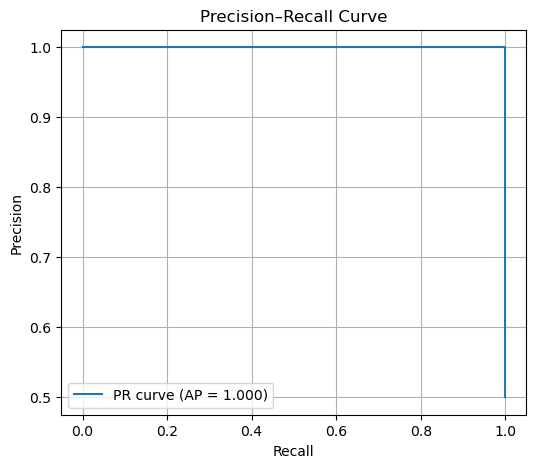

In [ ]:
y_test0 = ten_model_performance["Trial0"]["Gaussian Naive Bayes"]["y_test"]
y_score0 = ten_model_performance["Trial0"]["Gaussian Naive Bayes"]["y_score"]
precision, recall, _ = precision_recall_curve(y_test0, y_score0)
ap = average_precision_score(y_test0, y_score0)

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"PR curve (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(True)

plt.show()

In [48]:
os.getcwd()

'/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/PearsonXsel'

In [49]:
# Finger Crossed! It will take some time

for complex_name in all_complexes:
    print(f'It is the turn for {complex_name}')

    ten_model_performance = {}
    for i in range(10):
        print(f'Now, we are processing trial {i + 1}')
        pc_key = f'positive_control_{i+1}'
        nc_key = f'negative_controls_{i+1}'
        # Get the positive and negative sets
        this_pc = Ten_positive_controls_1119[pc_key]
        this_nc = Fixed_10_negative_controls[nc_key]


        train_pos_quan, train_neg_quan, test_pos_quan, test_neg_quan = QuantificationAPreparation(complex_name,
                                                                                                  this_pc, this_nc,
                                                                                                  "pearson", matrices,
                                                                                                  matrix_pairs)


        X_train, y_train, X_test, y_test = ready2model(train_pos_quan, train_neg_quan, test_pos_quan, test_neg_quan)

        if len(X_test) == 0:
            ten_model_performance[f'Trial{i}'] = None
            continue

        ten_model_performance[f'Trial{i}'] = modelFitting(X_train, y_train, X_test, y_test, True, True)

    safe_name = complex_name.replace(" ", "_")
    safe_name = re.sub(r'[^A-Za-z0-9_\-]', "", safe_name)

    with open(f'{safe_name}_10pearsonXsel_performance.pkl', "wb") as f:
        pickle.dump(ten_model_performance, f)

    
    print(f"Saved results for {complex_name}")

It is the turn for Cyclin–CDK complexes
Now, we are processing trial 1
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


/Users/guowanyi/miniconda3/envs/ML/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:05:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP Classifier Finished.
Now, we are processing trial 2
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


/Users/guowanyi/miniconda3/envs/ML/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:06:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP Classifier Finished.
Now, we are processing trial 3
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


...

MLP Classifier Finished.
Now, we are processing trial 9
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


/Users/guowanyi/miniconda3/envs/ML/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [19:19:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP Classifier Finished.
Now, we are processing trial 10
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


/Users/guowanyi/miniconda3/envs/ML/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [19:20:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP Classifier Finished.
Saved results for ISR/EIF2α–ATF4 complex


In [55]:
with open('/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/PearsonXsel/PI3KAKTmTOR_pathway_complexes_10pearsonXsel_performance.pkl', 'rb') as f:
    test_pearson = pickle.load(f)

In [56]:
test_pearson["Trial8"]

{'Gradient Boosting Classifier': {'train_accuracy': 1.0,
  'test_accuracy': 0.8,
  'precision': 0.8,
  'recall': 0.8,
  'f1_score': 0.8,
  'roc_auc': 0.8400000000000001,
  'y_test': 0    1
  1    1
  2    1
  3    1
  4    1
  5    0
  6    0
  7    0
  8    0
  9    0
  Name: Y, dtype: int64,
  'y_score': array([0.97653115, 0.98215028, 0.98988967, 0.11829957, 0.97419368,
         0.14335998, 0.14319529, 0.71177199, 0.32979471, 0.00185181]),
  'fpr': array([0. , 0. , 0. , 0.8, 0.8, 1. ]),
  'tpr': array([0. , 0.2, 0.8, 0.8, 1. , 1. ]),
  'precision_curve': array([0.5       , 0.55555556, 0.5       , 0.57142857, 0.66666667,
         0.8       , 1.        , 1.        , 1.        , 1.        ,
         1.        ]),
  'recall_curve': array([1. , 1. , 0.8, 0.8, 0.8, 0.8, 0.8, 0.6, 0.4, 0.2, 0. ])},
 'Gaussian Naive Bayes': {'train_accuracy': 0.8507462686567164,
  'test_accuracy': 1.0,
  'precision': 1.0,
  'recall': 1.0,
  'f1_score': 1.0,
  'roc_auc': 1.0,
  'y_test': 0    1
  1    1
  2  

### Spearman without feature selection

In [50]:
os.chdir('/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/SpearmanXsel')
os.getcwd()

'/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/SpearmanXsel'

In [57]:
# Finger Crossed! It will take some time

for complex_name in all_complexes:
    print(f'It is the turn for {complex_name}')

    ten_model_performance = {}
    for i in range(10):
        print(f'Now, we are processing trial {i + 1}')
        pc_key = f'positive_control_{i+1}'
        nc_key = f'negative_controls_{i+1}'
        # Get the positive and negative sets
        this_pc = Ten_positive_controls_1119[pc_key]
        this_nc = Fixed_10_negative_controls[nc_key]


        train_pos_quan, train_neg_quan, test_pos_quan, test_neg_quan = QuantificationAPreparation(complex_name,
                                                                                                  this_pc, this_nc,
                                                                                                  "spearman", matrices,
                                                                                                  matrix_pairs)


        X_train, y_train, X_test, y_test = ready2model(train_pos_quan, train_neg_quan, test_pos_quan, test_neg_quan)

        if len(X_test) == 0:
            ten_model_performance[f'Trial{i}'] = None
            continue

        ten_model_performance[f'Trial{i}'] = modelFitting(X_train, y_train, X_test, y_test, True, True)

    safe_name = complex_name.replace(" ", "_")
    safe_name = re.sub(r'[^A-Za-z0-9_\-]', "", safe_name)

    with open(f'{safe_name}_10spearmanXsel_performance.pkl', "wb") as f:
        pickle.dump(ten_model_performance, f)

    
    print(f"Saved results for {complex_name}")

It is the turn for Cyclin–CDK complexes
Now, we are processing trial 1
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


/Users/guowanyi/miniconda3/envs/ML/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [20:52:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP Classifier Finished.
Now, we are processing trial 2
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


/Users/guowanyi/miniconda3/envs/ML/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [20:53:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP Classifier Finished.
Now, we are processing trial 3
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


...

MLP Classifier Finished.
Now, we are processing trial 9
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


/Users/guowanyi/miniconda3/envs/ML/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [23:51:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP Classifier Finished.
Now, we are processing trial 10
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


/Users/guowanyi/miniconda3/envs/ML/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [23:51:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP Classifier Finished.
Saved results for ISR/EIF2α–ATF4 complex


### Mutual Information without feature selection

In [19]:
os.chdir('/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/MiXsel')
os.getcwd()

'/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/MiXsel'

In [17]:
# For each complex, iterate through ten independent positive and negative sets
ten_model_performance = {}
for i in range(10):
    print(f'Now, we are processing trial {i + 1}')
    pc_key = f'positive_control_{i+1}'
    nc_key = f'negative_controls_{i+1}'
    # Get the positive and negative sets
    this_pc = Ten_positive_controls_1119[pc_key]
    this_nc = Fixed_10_negative_controls[nc_key]


    train_pos_quan, train_neg_quan, test_pos_quan, test_neg_quan = QuantificationAPreparation(test_held_out_complex, 
                                                                                                        this_pc, 
                                                                                                        this_nc, 
                                                                                                        "mi", 
                                                                                                        matrices, 
                                                                                                        matrix_pairs)
    
    X_train, y_train, X_test, y_test = ready2model(train_pos_quan, train_neg_quan, test_pos_quan, test_neg_quan)

    if len(X_test) == 0:
        ten_model_performance[f'Trial{i}'] = None
        continue

    ten_model_performance[f'Trial{i}'] = modelFitting(X_train, y_train, X_test, y_test, True, True)

Now, we are processing trial 1
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


/Users/guowanyi/miniconda3/envs/ML/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [11:08:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP Classifier Finished.
Now, we are processing trial 2
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


/Users/guowanyi/miniconda3/envs/ML/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [11:09:14] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP Classifier Finished.
Now, we are processing trial 3
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


...

MLP Classifier Finished.
Now, we are processing trial 9
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


/Users/guowanyi/miniconda3/envs/ML/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [11:13:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP Classifier Finished.
Now, we are processing trial 10
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


/Users/guowanyi/miniconda3/envs/ML/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [11:14:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP Classifier Finished.


In [20]:
ten_model_performance["Trial6"]

{'Gradient Boosting Classifier': {'train_accuracy': 1.0,
  'test_accuracy': 1.0,
  'precision': 1.0,
  'recall': 1.0,
  'f1_score': 1.0,
  'roc_auc': 1.0,
  'y_test': 0    1
  1    1
  2    0
  3    0
  Name: Y, dtype: int64,
  'y_score': array([0.74078579, 0.908368  , 0.01997044, 0.06304789]),
  'fpr': array([0., 0., 0., 1.]),
  'tpr': array([0. , 0.5, 1. , 1. ]),
  'precision_curve': array([0.5       , 0.66666667, 1.        , 1.        , 1.        ]),
  'recall_curve': array([1. , 1. , 1. , 0.5, 0. ])},
 'Gaussian Naive Bayes': {'train_accuracy': 0.7588652482269503,
  'test_accuracy': 0.75,
  'precision': 1.0,
  'recall': 0.5,
  'f1_score': 0.6666666666666666,
  'roc_auc': 0.5,
  'y_test': 0    1
  1    1
  2    0
  3    0
  Name: Y, dtype: int64,
  'y_score': array([2.86279467e-04, 1.00000000e+00, 5.14512247e-02, 3.02116911e-04]),
  'fpr': array([0., 0., 1., 1.]),
  'tpr': array([0. , 0.5, 0.5, 1. ]),
  'precision_curve': array([0.5       , 0.33333333, 0.5       , 1.        , 1.    

In [21]:
test_held_out_complex

'ISR/EIF2α–ATF4 complex'

In [22]:
with open("ISR_EIF2a_ATF_complex_10miXsel_performance.pkl", "wb") as f:
    pickle.dump(ten_model_performance, f)

In [29]:
all_complexes[0:26]

['Cyclin–CDK complexes',
 'RB–E2F repressor complex',
 'ORC–MCM pre-replication complex',
 'Anaphase-Promoting Complex (APC/C)',
 'Cohesin complex',
 'MRN complex',
 'BRCA1–BARD1 complex',
 'Fanconi Anemia (FA) core complex',
 'ATR–CHK1 checkpoint complex',
 'PI3K–AKT–mTOR pathway complexes',
 'MAPK cascade',
 'LKB1–STRAD–MO25 complex',
 'AMPK complex',
 'BCL-2 family complexes',
 'Death-Inducing Signaling Complex (DISC)',
 'Apoptosome',
 'NF-κB transcriptional complex',
 'Inflammasome',
 'Autophagy initiation complex',
 'SWI/SNF (BAF/PBAF) complex',
 'TIP60/NuA4 complex',
 'PRC2 complex',
 'Mediator/CDK8 module',
 'p53 regulatory network',
 'Proteasome complex',
 'HSP90–CDC37 chaperone complex']

In [30]:
# Finger Crossed! It will take some time

for complex_name in all_complexes[0:26]:
    print(f'It is the turn for {complex_name}')

    ten_model_performance = {}
    for i in range(10):
        print(f'Now, we are processing trial {i + 1}')
        pc_key = f'positive_control_{i+1}'
        nc_key = f'negative_controls_{i+1}'
        # Get the positive and negative sets
        this_pc = Ten_positive_controls_1119[pc_key]
        this_nc = Fixed_10_negative_controls[nc_key]


        train_pos_quan, train_neg_quan, test_pos_quan, test_neg_quan = QuantificationAPreparation(complex_name,
                                                                                                  this_pc, this_nc,
                                                                                                  "mi", matrices,
                                                                                                  matrix_pairs)


        X_train, y_train, X_test, y_test = ready2model(train_pos_quan, train_neg_quan, test_pos_quan, test_neg_quan)

        if len(X_test) == 0:
            ten_model_performance[f'Trial{i}'] = None
            continue

        ten_model_performance[f'Trial{i}'] = modelFitting(X_train, y_train, X_test, y_test, True, True)

    safe_name = complex_name.replace(" ", "_")
    safe_name = re.sub(r'[^A-Za-z0-9_\-]', "", safe_name)

    with open(f'{safe_name}_10miXsel_performance.pkl', "wb") as f:
        pickle.dump(ten_model_performance, f)

    
    print(f"Saved results for {complex_name}")

It is the turn for Cyclin–CDK complexes
Now, we are processing trial 1
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


/Users/guowanyi/miniconda3/envs/ML/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [11:24:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP Classifier Finished.
Now, we are processing trial 2
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


/Users/guowanyi/miniconda3/envs/ML/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [11:25:01] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP Classifier Finished.
Now, we are processing trial 3
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


...

MLP Classifier Finished.
Now, we are processing trial 9
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


/Users/guowanyi/miniconda3/envs/ML/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:10:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP Classifier Finished.
Now, we are processing trial 10
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


/Users/guowanyi/miniconda3/envs/ML/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:11:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP Classifier Finished.
Saved results for HSP90–CDC37 chaperone complex


### Bicor without feature selection

In [31]:
os.chdir('/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/BicorXsel')
os.getcwd()

'/Users/guowanyi/Desktop/spring 2026/Louis_Vuitton/March 11 update/BicorXsel'

In [32]:
bicor_feature_pairs = [
    ("CRISPR", "CRISPR"),
    ("Gene_expression", "Gene_expression"),
    ("shRNA", "shRNA"),
    ("CRISPR", "Gene_expression"),
    ("CRISPR", "shRNA"),
    ("shRNA", "CRISPR"),
    ("Gene_expression", "shRNA"),
    ("Gene_expression", "CRISPR"),
    ("shRNA", "Gene_expression")
]

In [33]:
# Finger Crossed! It will take some time

for complex_name in all_complexes:
    print(f'It is the turn for {complex_name}')

    ten_model_performance = {}
    for i in range(10):
        print(f'Now, we are processing trial {i + 1}')
        pc_key = f'positive_control_{i+1}'
        nc_key = f'negative_controls_{i+1}'
        # Get the positive and negative sets
        this_pc = Ten_positive_controls_1119[pc_key]
        this_nc = Fixed_10_negative_controls[nc_key]


        train_pos_quan, train_neg_quan, test_pos_quan, test_neg_quan = QuantificationAPreparation(complex_name,
                                                                                                  this_pc, this_nc,
                                                                                                  "bicor", matrices,
                                                                                                  bicor_feature_pairs)


        X_train, y_train, X_test, y_test = ready2model(train_pos_quan, train_neg_quan, test_pos_quan, test_neg_quan)

        if len(X_test) == 0:
            ten_model_performance[f'Trial{i}'] = None
            continue

        ten_model_performance[f'Trial{i}'] = modelFitting(X_train, y_train, X_test, y_test, False)

    safe_name = complex_name.replace(" ", "_")
    safe_name = re.sub(r'[^A-Za-z0-9_\-]', "", safe_name)

    with open(f'{safe_name}_10bicorXsel_performance.pkl', "wb") as f:
        pickle.dump(ten_model_performance, f)

    
    print(f"Saved results for {complex_name}")

It is the turn for Cyclin–CDK complexes
Now, we are processing trial 1
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


/Users/guowanyi/miniconda3/envs/ML/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:19:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP Classifier Finished.
Now, we are processing trial 2
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


/Users/guowanyi/miniconda3/envs/ML/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:19:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP Classifier Finished.
Now, we are processing trial 3
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


...

MLP Classifier Finished.
Now, we are processing trial 9
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


/Users/guowanyi/miniconda3/envs/ML/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:24:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP Classifier Finished.
Now, we are processing trial 10
Gradient Boosting Classifier Finished.
Gaussian Naive Bayes Finished.
XGBoosting Finished.
Logistic Regression Finished.
Support Vector Classifier Finished.


/Users/guowanyi/miniconda3/envs/ML/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [15:24:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MLP Classifier Finished.
Saved results for ISR/EIF2α–ATF4 complex
